# Training vs Generated Data Analysis

Compares aggregate statistics, distributions and temporal structure between:
- **Reference**: the first `TRAINING_DATASET_SIZE` CSVs from the training directory (sorted)
- **Generated**: all CSVs produced by the reverse-diffusion model

Both datasets are either log-prices or log-returns.
Reference paths may be full-length stock histories; generated paths are fixed-length windows.

In [1]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
REF_DIRECTORY         = "../data/replication_returns_other"          # training data folder
GEN_DIRECTORY         = "../data/generated/replication/ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-400_sde-ve_noise-linear_20260502_173907_N2000_seed97"
SEED                  = 50
TRAINING_SEED         = 97    # must match config["train"]["seed"] used during training
VAL_SPLIT_RATIO       = 0.05 # set to e.g. 0.1 if --val_split_ratio was used; else None
TRAINING_DATASET_SIZE = None   # number of sliding windows — mirrors --train_subset_size
                               # set to None to use all available (post-val) windows
SEQ_LEN               = 2048  # window length used during training (--seq_len)
STRIDE                = 400   # stride used during training (--stride)
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf as sm_acf

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"REF_DIRECTORY         : {REF_DIRECTORY}")
print(f"GEN_DIRECTORY         : {GEN_DIRECTORY}")
print(f"SEED                  : {SEED}")
print(f"TRAINING_DATASET_SIZE : {TRAINING_DATASET_SIZE}")
print(f"SEQ_LEN               : {SEQ_LEN}")
print(f"STRIDE                : {STRIDE}")

REF_DIRECTORY         : ../data/replication_returns_other
GEN_DIRECTORY         : ../data/generated/replication/ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-400_sde-ve_noise-linear_20260502_173907_N2000_seed97
SEED                  : 50
TRAINING_DATASET_SIZE : None
SEQ_LEN               : 2048
STRIDE                : 400


## 1. Load data

In [3]:
# ── Reference data ────────────────────────────────────────────────────────────
# Mirrors csdi_train_modified.py exactly:
#   1. Load ALL sorted CSVs — no file cap
#   2. Extract sliding windows with same SEQ_LEN / STRIDE / drop_incomplete=True
#   3. Replicate torch.randperm(seed) + val split + train_subset_size
import torch

ref_csv_files = sorted(Path(REF_DIRECTORY).glob("*.csv"))
if len(ref_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {REF_DIRECTORY}")

all_windows: list[np.ndarray] = []
n_skipped_short = 0
for fp in ref_csv_files:
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    T = len(series)
    max_start = T - SEQ_LEN
    if max_start < 0:   # shorter than SEQ_LEN — skip (drop_incomplete=True)
        n_skipped_short += 1
        continue
    for s in range(0, max_start + 1, STRIDE):
        all_windows.append(series[s : s + SEQ_LEN])

if n_skipped_short:
    print(f"[WARNING] {n_skipped_short} file(s) shorter than SEQ_LEN={SEQ_LEN} were skipped.")
if len(all_windows) == 0:
    raise RuntimeError("No windows could be extracted. Check SEQ_LEN / STRIDE / REF_DIRECTORY.")

print(f"Total windows in full dataset : {len(all_windows)} "
      f"(from {len(ref_csv_files) - n_skipped_short} usable file(s), "
      f"SEQ_LEN={SEQ_LEN}, STRIDE={STRIDE})")

# ── Replicate training subset selection with torch RNG ────────────────────────
torch_rng  = torch.Generator().manual_seed(TRAINING_SEED)
all_indices = torch.randperm(len(all_windows), generator=torch_rng).tolist()

# Carve out val split first (mirrors val_split_ratio logic in training script)
if VAL_SPLIT_RATIO is not None:
    val_size   = max(1, int(len(all_windows) * VAL_SPLIT_RATIO))
    train_pool = all_indices[val_size:]
    print(f"Val split : {val_size} windows held out (VAL_SPLIT_RATIO={VAL_SPLIT_RATIO})")
else:
    train_pool = all_indices

# Then take TRAINING_DATASET_SIZE from the remaining pool
if TRAINING_DATASET_SIZE is not None and TRAINING_DATASET_SIZE < len(train_pool):
    train_indices = train_pool[:TRAINING_DATASET_SIZE]
    print(f"Reference : {len(train_indices)} windows "
          f"(TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} of {len(train_pool)} in pool)")
else:
    train_indices = train_pool
    if TRAINING_DATASET_SIZE is not None:
        print(f"[WARNING] TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} >= pool size "
              f"({len(train_pool)}); using all pool windows.")
    print(f"Reference : {len(train_indices)} windows (full training pool)")

ref_paths = [all_windows[i] for i in train_indices]

assert all(len(w) == SEQ_LEN for w in ref_paths), "Window length mismatch — check SEQ_LEN"
print(f"  All window lengths = {SEQ_LEN}  ✓")

Total windows in full dataset : 5568 (from 210 usable file(s), SEQ_LEN=2048, STRIDE=400)
Val split : 278 windows held out (VAL_SPLIT_RATIO=0.05)
Reference : 5290 windows (full training pool)
  All window lengths = 2048  ✓


In [4]:
# ── Generated data ────────────────────────────────────────────────────────────
# Load ALL CSV files in GEN_DIRECTORY (no size cap).
# Two formats are supported:
#   (a) Per-sample CSVs  — columns: date, log_adj_close  (one file per path)
#   (b) Wide-format CSV  — columns: sample_idx, start_date, end_date, step_000, step_001, ...
#       (produced by generate_samples.py as "generated_samples.csv")
gen_csv_files = sorted(Path(GEN_DIRECTORY).glob("*.csv"))

if len(gen_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {GEN_DIRECTORY}")

gen_paths: list[np.ndarray] = []
skipped = 0
for fp in gen_csv_files:
    df = pd.read_csv(fp)
    if "log_adj_close" in df.columns:
        # Format (a): individual per-sample CSV
        gen_paths.append(df["log_adj_close"].values.astype(np.float64))
    else:
        # Format (b): wide-format — each row is one sample path
        step_cols = sorted(
            [c for c in df.columns if c.startswith("step_")],
            key=lambda c: int(c.split("_")[1])
        )
        print(step_cols[999:], f"\n first column: {step_cols[0]}, last column: {step_cols[-1]}")
        if step_cols:
            print(df.head())
            for _, row in df.iterrows():
                gen_paths.append(row[step_cols].values.astype(np.float64))
        else:
            skipped += 1

if skipped:
    print(f"[WARNING] Skipped {skipped} file(s) with unrecognised column layout.")
if len(gen_paths) == 0:
    raise RuntimeError("No valid generated paths could be loaded from GEN_DIRECTORY.")

gen_lens = [len(p) for p in gen_paths]
print(f"Generated: {len(gen_paths)} paths loaded  ({len(gen_csv_files)} CSV file(s) read)")
print(f"  Path lengths — min={min(gen_lens)}  max={max(gen_lens)}  "
      f"median={int(np.median(gen_lens))}")

print(gen_paths[0][:5], "\n", gen_paths[0][-5:])
print(gen_paths[-1][:5], "\n", gen_paths[-1][-5:])

['step_999', 'step_1000', 'step_1001', 'step_1002', 'step_1003', 'step_1004', 'step_1005', 'step_1006', 'step_1007', 'step_1008', 'step_1009', 'step_1010', 'step_1011', 'step_1012', 'step_1013', 'step_1014', 'step_1015', 'step_1016', 'step_1017', 'step_1018', 'step_1019', 'step_1020', 'step_1021', 'step_1022', 'step_1023', 'step_1024', 'step_1025', 'step_1026', 'step_1027', 'step_1028', 'step_1029', 'step_1030', 'step_1031', 'step_1032', 'step_1033', 'step_1034', 'step_1035', 'step_1036', 'step_1037', 'step_1038', 'step_1039', 'step_1040', 'step_1041', 'step_1042', 'step_1043', 'step_1044', 'step_1045', 'step_1046', 'step_1047', 'step_1048', 'step_1049', 'step_1050', 'step_1051', 'step_1052', 'step_1053', 'step_1054', 'step_1055', 'step_1056', 'step_1057', 'step_1058', 'step_1059', 'step_1060', 'step_1061', 'step_1062', 'step_1063', 'step_1064', 'step_1065', 'step_1066', 'step_1067', 'step_1068', 'step_1069', 'step_1070', 'step_1071', 'step_1072', 'step_1073', 'step_1074', 'step_1075',

## 2. Aggregate statistics

In [5]:
def compute_stats(paths: list[np.ndarray], label: str) -> dict:
    flat = np.concatenate(paths)
    incs = np.concatenate([np.diff(p) for p in paths if len(p) > 1])
    return {
        "label"            : label,
        "n_paths"          : len(paths),
        "n_values"         : len(flat),
        "mean"             : flat.mean(),
        "std"              : flat.std(),
        "min"              : flat.min(),
        "q01"              : np.quantile(flat, 0.01),
        "q05"              : np.quantile(flat, 0.05),
        "q25"              : np.quantile(flat, 0.25),
        "q50"              : np.quantile(flat, 0.50),
        "q75"              : np.quantile(flat, 0.75),
        "q95"              : np.quantile(flat, 0.95),
        "q99"              : np.quantile(flat, 0.99),
        "max"              : flat.max(),
        "skewness"         : scipy_stats.skew(flat),
        "excess_kurtosis"  : scipy_stats.kurtosis(flat, fisher=True),
        "inc_mean"         : incs.mean(),
        "inc_std"          : incs.std(),
        "inc_min"          : incs.min(),
        "inc_q01"          : np.quantile(incs, 0.01),
        "inc_q99"          : np.quantile(incs, 0.99),
        "inc_max"          : incs.max(),
        "inc_skewness"     : scipy_stats.skew(incs),
        "inc_excess_kurt"  : scipy_stats.kurtosis(incs, fisher=True),
    }

ref_stats = compute_stats(ref_paths, "Reference (training)")
gen_stats = compute_stats(gen_paths, "Generated")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels = pd.DataFrame(
    {k: {"Reference": ref_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels.style.format("{:.4f}"))

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference,Generated
n_paths,5290.0000,512.0000
n_values,10833920.0000,1048576.0000
mean,0.0005,0.0006
std,0.0208,0.0213
min,-0.9363,-0.9564
q01,-0.0562,-0.0534
q05,-0.0291,-0.0315
q25,-0.0086,-0.0113
q50,0.0000,0.0005
q75,0.0095,0.0124


In [ ]:
for paths, label in [(ref_paths, "Reference"), (gen_paths, "GenWerated")]:
    flat = np.concatenate(paths)
    zero_pct = 100.0 * np.mean(flat == 0.0)
    print(f"{label}: {zero_pct:.4f}% absolute zeros ({(flat == 0.0).sum()} / {len(flat)})")


Reference: 7.1872% absolute zeros (778656 / 10833920)
Generated: 0.0000% absolute zeros (0 / 1048576)


In [6]:
# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs = pd.DataFrame(
    {rename[k]: {"Reference": ref_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs.style.format("{:.4f}"))

  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference,Generated
mean,0.0000,-0.0000
std,0.0296,0.0300
min,-1.3863,-0.9700
q01,-0.0806,-0.0759
q99,0.0821,0.0768
max,1.0291,0.9471
skewness,0.2571,0.1188
excess_kurtosis,26.8795,10.2737


## 2b. Aggregate statistics — full stock series vs generated

In [7]:
# Load full stock series from REF_DIRECTORY (one per stock, no windowing)
ref_full_paths = []
for fp in sorted(Path(REF_DIRECTORY).glob("*.csv")):
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    ref_full_paths.append(series)

print(f"Full stock series loaded : {len(ref_full_paths)}")
print(f"Lengths — min={min(len(s) for s in ref_full_paths)}  "
      f"max={max(len(s) for s in ref_full_paths)}  "
      f"mean={np.mean([len(s) for s in ref_full_paths]):.0f}")

ref_full_stats = compute_stats(ref_full_paths, "Reference (full series)")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels_full = pd.DataFrame(
    {k: {"Reference (full)": ref_full_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("\n" + "=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels_full.style.format("{:.4f}"))

# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs_full = pd.DataFrame(
    {rename[k]: {"Reference (full)": ref_full_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("\n" + "=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs_full.style.format("{:.4f}"))

Full stock series loaded : 210
Lengths — min=10083  max=16175  mean=12493

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference (full),Generated
n_paths,210.0000,512.0000
n_values,2623490.0000,1048576.0000
mean,0.0005,0.0006
std,0.0209,0.0213
min,-0.9363,-0.9564
q01,-0.0564,-0.0534
q05,-0.0292,-0.0315
q25,-0.0086,-0.0113
q50,0.0000,0.0005
q75,0.0095,0.0124



  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference (full),Generated
mean,-0.0000,-0.0000
std,0.0297,0.0300
min,-1.3863,-0.9700
q01,-0.0805,-0.0759
q99,0.0820,0.0768
max,1.0291,0.9471
skewness,0.2227,0.1188
excess_kurtosis,29.4105,10.2737


## Per-window statistics

Per-window statistics — summary (mean ± std across windows)


,Reference mean,Reference std,Generated mean,Generated std
mean,0.0005,0.0004,0.0006,0.0005
std,0.0196,0.0069,0.0208,0.0044
skewness,-0.3344,1.3650,-0.1879,1.0608
excess_kurt,14.0974,36.0037,7.3777,31.9534
zero_ratio,0.0719,0.0938,0.0000,0.0000
inc_std,0.0279,0.0100,0.0294,0.0062
inc_skewness,0.2386,0.5023,0.1006,0.2284
inc_excess_kurt,11.3291,22.8639,5.1430,16.7992


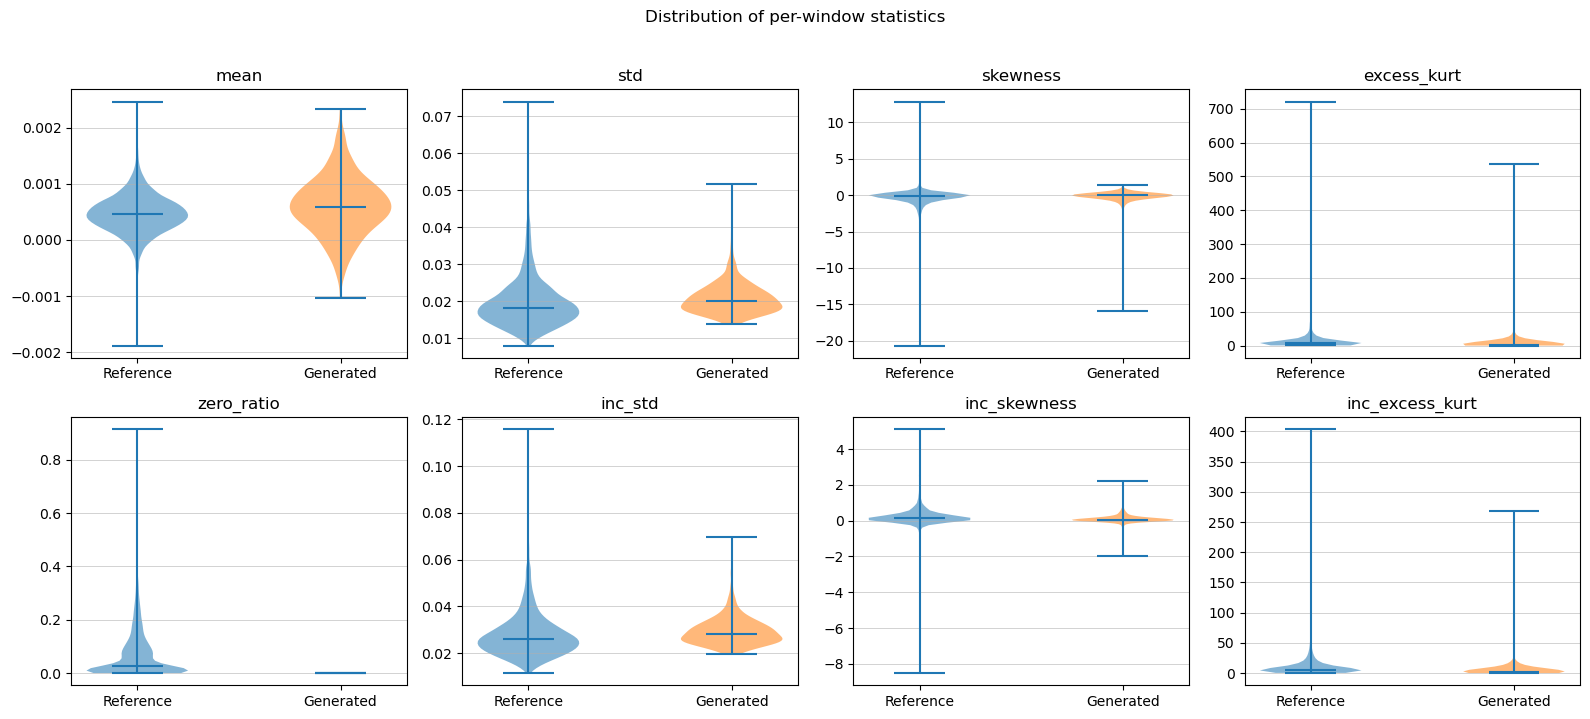

In [8]:
def per_window_stats(paths: list[np.ndarray]) -> pd.DataFrame:
    rows = []
    for p in paths:
        incs = np.diff(p)
        rows.append({
            "mean"         : float(p.mean()),
            "std"          : float(p.std()),
            "skewness"     : float(scipy_stats.skew(p)),
            "excess_kurt"  : float(scipy_stats.kurtosis(p, fisher=True)),
            "zero_ratio"   : float(np.mean(p == 0.0)),
            "inc_std"      : float(incs.std()),
            "inc_skewness" : float(scipy_stats.skew(incs)),
            "inc_excess_kurt": float(scipy_stats.kurtosis(incs, fisher=True)),
        })
    return pd.DataFrame(rows)

ref_pw = per_window_stats(ref_paths)
gen_pw = per_window_stats(gen_paths)

# ── Summary table: mean ± std of each per-window stat ────────────────────────
summary = pd.DataFrame({
    "Reference  mean": ref_pw.mean(),
    "Reference  std" : ref_pw.std(),
    "Generated  mean": gen_pw.mean(),
    "Generated  std" : gen_pw.std(),
}).round(5)
print("Per-window statistics — summary (mean ± std across windows)")
display(summary.style.format("{:.4f}"))

# ── Violin plots ──────────────────────────────────────────────────────────────
metrics = list(ref_pw.columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, metric in zip(axes.flat, metrics):
    data  = [ref_pw[metric].values, gen_pw[metric].values]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor("tab:blue");   parts["bodies"][0].set_alpha(0.55)
    parts["bodies"][1].set_facecolor("tab:orange"); parts["bodies"][1].set_alpha(0.55)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Reference", "Generated"])
    ax.set_title(metric)
    ax.grid(axis="y", linewidth=0.4)

plt.suptitle("Distribution of per-window statistics", y=1.02)
plt.tight_layout()
plt.show()


### Kurtosis offenders

The top offenders are identified through computation of the increments so as to identify most leptokurtic distribution, which have very fat tails and sharp peaks.

In [9]:
# ── Kurtosis diagnosis: worst windows by increment excess kurtosis ─────────────
TOP_K      = 10   # number of worst windows to inspect
TOP_N_INCS = 5    # largest increments to report per window

def print_worst_kurtosis_windows(pw: pd.DataFrame, paths: list, label: str,
                                  top_k: int, top_n: int) -> None:
    worst = pw.nlargest(top_k, "inc_excess_kurt")
    print(f"{'='*70}")
    print(f"Top-{top_k} {label} windows by increment excess kurtosis")
    print(f"{'='*70}\n")
    for rank, (win_idx, row) in enumerate(worst.iterrows(), start=1):
        path     = paths[win_idx]
        incs     = np.diff(path)
        abs_incs = np.abs(incs)
        print(f"Rank {rank:2d} | window index {win_idx}")
        print(f"  {'mean':<20s}: {row['mean']:+.6f}")
        print(f"  {'std':<20s}: {row['std']:.6f}")
        print(f"  {'skewness':<20s}: {row['skewness']:+.4f}")
        print(f"  {'excess_kurt (levels)':<20s}: {row['excess_kurt']:+.4f}")
        print(f"  {'inc_std':<20s}: {row['inc_std']:.6f}")
        print(f"  {'inc_skewness':<20s}: {row['inc_skewness']:+.4f}")
        print(f"  {'inc_excess_kurt':<20s}: {row['inc_excess_kurt']:+.4f}")
        top_pos = np.argsort(abs_incs)[::-1][:top_n]
        print(f"\n  Top-{top_n} largest |Δx_t|  (position l in [0, {len(incs)-1}]):")
        print(f"  {'l':>6}  {'Δx':>12}  {'|Δx|':>10}  {'x[l]':>12}  {'x[l+1]':>12}")
        for pos in top_pos:
            print(f"  {pos:>6d}  {incs[pos]:>+12.6f}  {abs_incs[pos]:>10.6f}"
                  f"  {path[pos]:>+12.6f}  {path[pos+1]:>+12.6f}")
        print()

print_worst_kurtosis_windows(gen_pw, gen_paths, "Generated", TOP_K, TOP_N_INCS)
print_worst_kurtosis_windows(ref_pw, ref_paths, "Reference", TOP_K, TOP_N_INCS)

Top-10 Generated windows by increment excess kurtosis

Rank  1 | window index 24
  mean                : +0.000246
  std                 : 0.029599
  skewness            : -15.9755
  excess_kurt (levels): +535.9811
  inc_std             : 0.041934
  inc_skewness        : -0.4756
  inc_excess_kurt     : +268.1556

  Top-5 largest |Δx_t|  (position l in [0, 2046]):
       l            Δx        |Δx|          x[l]        x[l+1]
    1758     -0.969974    0.969974     +0.013592     -0.956382
    1759     +0.947096    0.947096     -0.956382     -0.009285
     469     -0.323070    0.323070     +0.300405     -0.022666
     468     +0.312921    0.312921     -0.012517     +0.300405
    1185     -0.160429    0.160429     +0.035521     -0.124908

Rank  2 | window index 304
  mean                : -0.000180
  std                 : 0.026522
  skewness            : -14.7658
  excess_kurt (levels): +458.4474
  inc_std             : 0.037860
  inc_skewness        : -1.9663
  inc_excess_kurt     : +244.

In [10]:
# ── Aggregate statistics after removing the N_DROP most leptokurtic windows ───
N_DROP = 15   # number of worst-kurtosis windows to exclude from each dataset

gen_drop_idx = set(gen_pw.nlargest(N_DROP, "inc_excess_kurt").index)
ref_drop_idx = set(ref_pw.nlargest(N_DROP, "inc_excess_kurt").index)

gen_paths_trim = [p for i, p in enumerate(gen_paths) if i not in gen_drop_idx]
ref_paths_trim = [p for i, p in enumerate(ref_paths) if i not in ref_drop_idx]

print(f"Generated : {len(gen_paths)} → {len(gen_paths_trim)} windows "
      f"(removed {len(gen_drop_idx)} most leptokurtic)")
print(f"Reference : {len(ref_paths)} → {len(ref_paths_trim)} windows "
      f"(removed {len(ref_drop_idx)} most leptokurtic)\n")

ref_stats_trim = compute_stats(ref_paths_trim, "Reference (trimmed)")
gen_stats_trim = compute_stats(gen_paths_trim, "Generated (trimmed)")

keys = ["mean", "std", "min", "q01", "q99", "max", "skewness", "excess_kurtosis",
        "inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99", "inc_max",
        "inc_skewness", "inc_excess_kurt"]

df_cmp = pd.DataFrame({
    "Gen  full"   : {k: gen_stats[k]      for k in keys},
    "Gen  trimmed": {k: gen_stats_trim[k] for k in keys},
    "Ref  full"   : {k: ref_stats[k]      for k in keys},
    "Ref  trimmed": {k: ref_stats_trim[k] for k in keys},
}).round(6)

print(f"Aggregate statistics — full vs trimmed (top-{N_DROP} leptokurtic windows removed)")
display(df_cmp.style.format("{:.6f}"))

Generated : 512 → 497 windows (removed 15 most leptokurtic)
Reference : 5290 → 5275 windows (removed 15 most leptokurtic)

Aggregate statistics — full vs trimmed (top-15 leptokurtic windows removed)


,Gen full,Gen trimmed,Ref full,Ref trimmed
mean,0.000603,0.000609,0.000461,0.000462
std,0.021270,0.021137,0.020808,0.020803
min,-0.956382,-0.626659,-0.936258,-0.936258
q01,-0.053419,-0.053348,-0.056193,-0.056218
q99,0.055915,0.055834,0.058269,0.058286
max,0.363990,0.353025,0.693147,0.693147
skewness,-0.294529,-0.115267,-0.533794,-0.479785
excess_kurtosis,15.466624,7.441855,36.007014,34.132391
inc_mean,-0.000001,-0.000002,0.000000,0.000000
inc_std,0.030029,0.029828,0.029623,0.029617


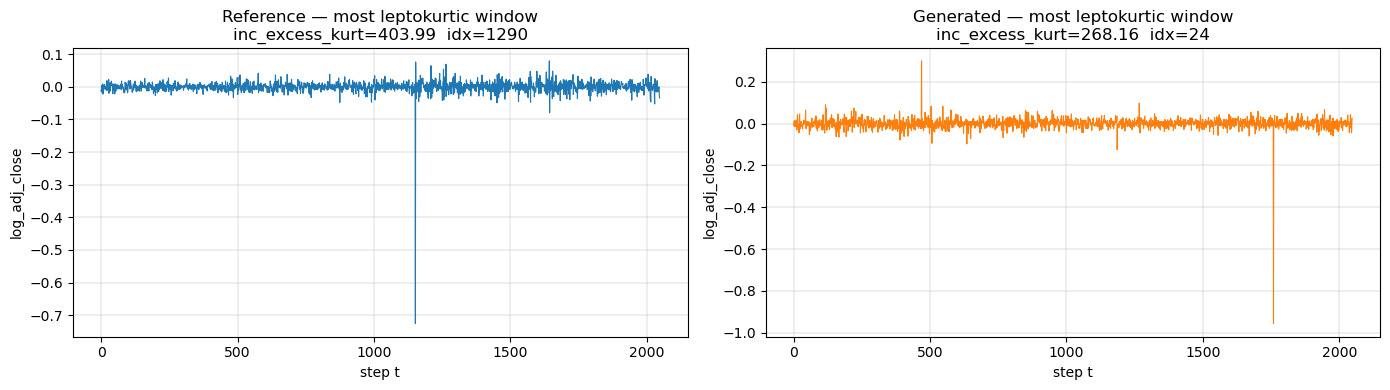

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (pw, paths, label, color) in zip(axes, [
    (ref_pw, ref_paths, "Reference", "tab:blue"),
    (gen_pw, gen_paths, "Generated", "tab:orange"),
]):
    worst_idx = pw["inc_excess_kurt"].idxmax()
    p = paths[worst_idx]
    ax.plot(p, linewidth=0.8, color=color)
    ax.set_title(f"{label} — most leptokurtic window\n"
                 f"inc_excess_kurt={pw.loc[worst_idx, 'inc_excess_kurt']:.2f}  "
                 f"idx={worst_idx}")
    ax.set_xlabel("step t")
    ax.set_ylabel("log_adj_close")
    ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()


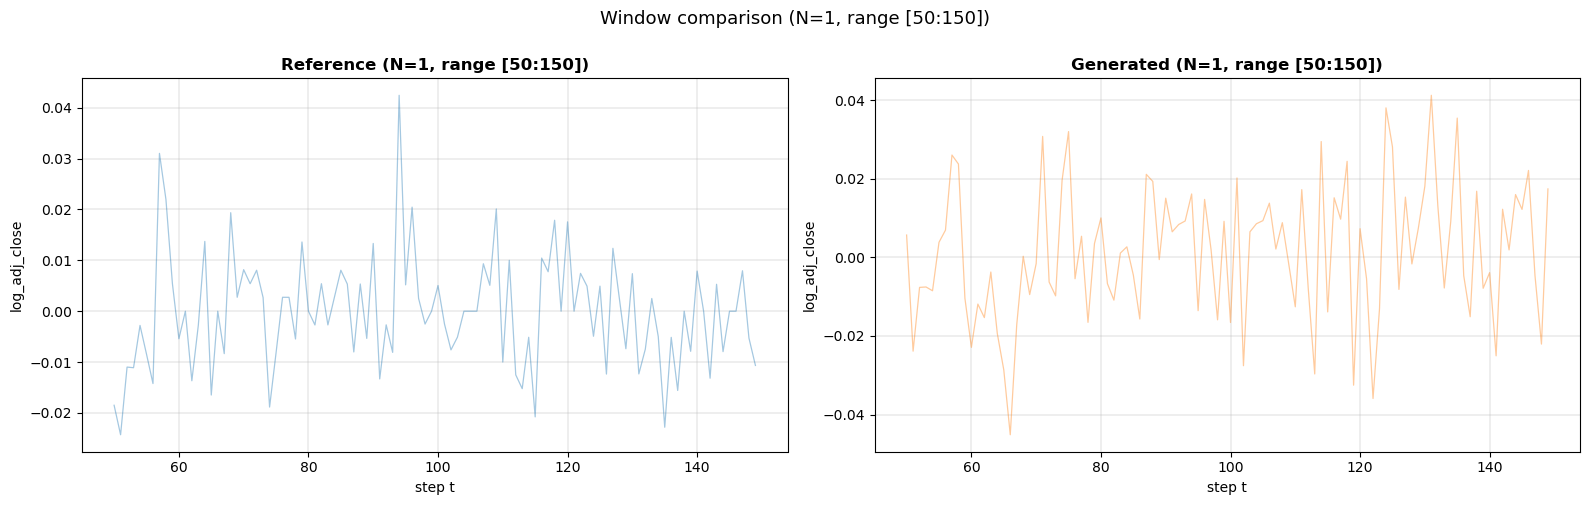

Plotted 1 reference and 1 generated paths
Range: [50:150]


In [12]:
# ── Compare N individual windows with custom range (user-specified) ──────────
N_WINDOWS = 1     # ← change this to select how many paths to visualize
START_IDX = 50       # ← start index (0 = beginning)
END_IDX   = 150   # ← end index (None = full length, or e.g. 500, 1000, etc.)

n_ref = min(N_WINDOWS, len(ref_paths))
n_gen = min(N_WINDOWS, len(gen_paths))

ref_idx = rng.choice(len(ref_paths), size=n_ref, replace=False)
gen_idx = rng.choice(len(gen_paths), size=n_gen, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Reference paths ─────────────────────────────────────────────────────────
ax = axes[0]
for i in ref_idx:
    p = ref_paths[i][START_IDX:END_IDX]
    ax.plot(np.arange(START_IDX, START_IDX + len(p)), p, 
            alpha=0.4, linewidth=0.9, color="tab:blue")
ax.set_title(f"Reference (N={n_ref}, range [{START_IDX}:{END_IDX}])", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close")
ax.grid(True, linewidth=0.3)

# ── Generated paths ─────────────────────────────────────────────────────────
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i][START_IDX:END_IDX]
    ax.plot(np.arange(START_IDX, START_IDX + len(p)), p, 
            alpha=0.4, linewidth=0.9, color="tab:orange")
ax.set_title(f"Generated (N={n_gen}, range [{START_IDX}:{END_IDX}])", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close")
ax.grid(True, linewidth=0.3)

plt.suptitle(f"Window comparison (N={N_WINDOWS}, range [{START_IDX}:{END_IDX}])", 
             y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Plotted {n_ref} reference and {n_gen} generated paths")
print(f"Range: [{START_IDX}:{END_IDX}]")


## 3. Level distribution: histogram, QQ plot, ECDF

In [13]:
gen_checkpoint_name = os.path.basename(GEN_DIRECTORY.rstrip('/'))
ref_checkpoint_name = os.path.basename(REF_DIRECTORY.rstrip('/'))

Levels KS statistic = 0.0554  |  p-value = 0.0000e+00


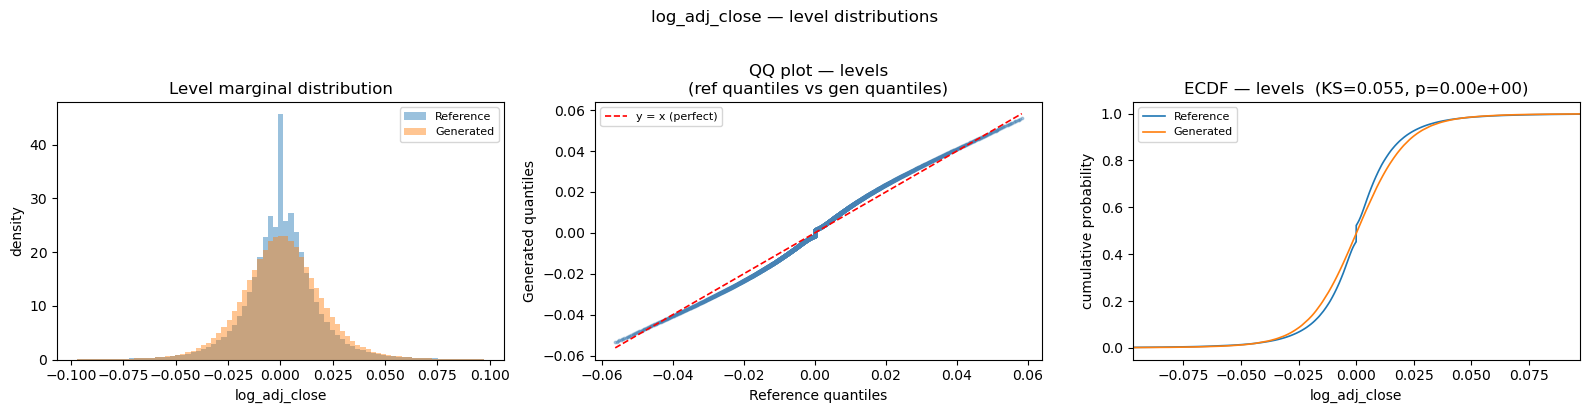

In [14]:
ref_flat = np.concatenate(ref_paths)
gen_flat = np.concatenate(gen_paths)

ks_stat_lev, ks_p_lev = scipy_stats.ks_2samp(ref_flat, gen_flat)
print(f"Levels KS statistic = {ks_stat_lev:.4f}  |  p-value = {ks_p_lev:.4e}")

combined = np.concatenate([ref_flat, gen_flat])
lo, hi   = np.quantile(combined, [0.002, 0.998])
bins     = np.linspace(lo, hi, 80)
xs       = np.linspace(lo, hi, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_flat, bins=bins, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Level marginal distribution")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot (ref quantiles vs gen quantiles)
ax = axes[1]
n_q  = min(len(ref_flat), len(gen_flat), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref = np.quantile(ref_flat, probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — levels\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_flat, "Reference", "tab:blue"),
    (gen_flat, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF — levels  (KS={ks_stat_lev:.3f}, p={ks_p_lev:.2e})")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("log_adj_close — level distributions", y=1.02)
plt.tight_layout()
plt.savefig(f"../images/comparison/level_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 4. Increment distribution: histogram, QQ plot, ECDF

Increments KS statistic = 0.0503  |  p-value = 0.0000e+00


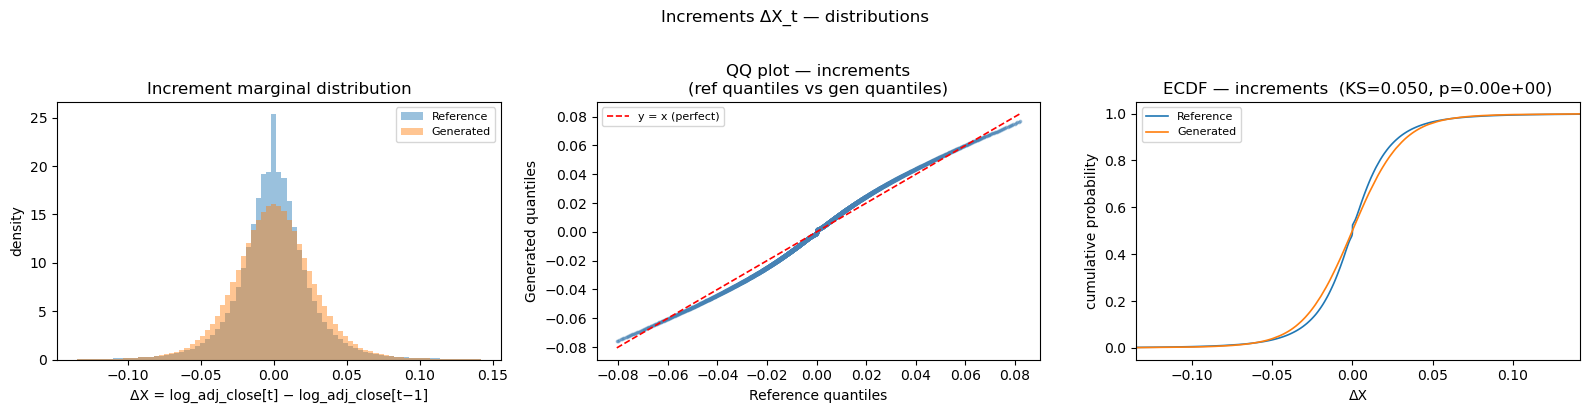

In [15]:
ref_incs = np.concatenate([np.diff(p) for p in ref_paths if len(p) > 1])
gen_incs = np.concatenate([np.diff(p) for p in gen_paths if len(p) > 1])

ks_stat_inc, ks_p_inc = scipy_stats.ks_2samp(ref_incs, gen_incs)
print(f"Increments KS statistic = {ks_stat_inc:.4f}  |  p-value = {ks_p_inc:.4e}")

combined_inc = np.concatenate([ref_incs, gen_incs])
lo_i, hi_i  = np.quantile(combined_inc, [0.002, 0.998])
bins_i      = np.linspace(lo_i, hi_i, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_incs, bins=bins_i, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_incs, bins=bins_i, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Increment marginal distribution")
ax.set_xlabel("ΔX = log_adj_close[t] − log_adj_close[t−1]")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot
ax = axes[1]
n_q  = min(len(ref_incs), len(gen_incs), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref_i = np.quantile(ref_incs, probs)
q_gen_i = np.quantile(gen_incs, probs)
ax.scatter(q_ref_i, q_gen_i, s=3, alpha=0.4, color="steelblue")
lims_i = [min(q_ref_i.min(), q_gen_i.min()), max(q_ref_i.max(), q_gen_i.max())]
ax.plot(lims_i, lims_i, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — increments\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_incs, "Reference", "tab:blue"),
    (gen_incs, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo_i, hi_i)
ax.set_title(f"ECDF — increments  (KS={ks_stat_inc:.3f}, p={ks_p_inc:.2e})")
ax.set_xlabel("ΔX")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("Increments ΔX_t — distributions", y=1.02)
plt.tight_layout()
plt.savefig(f"../images/comparison/increments_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 5. Sample paths

Visual check: do the shapes, scale, and fan-out look alike?

Reference paths may be longer; if so, a random window of the generated-path length is
extracted (using `SEED`) for a fair apples-to-apples visual.

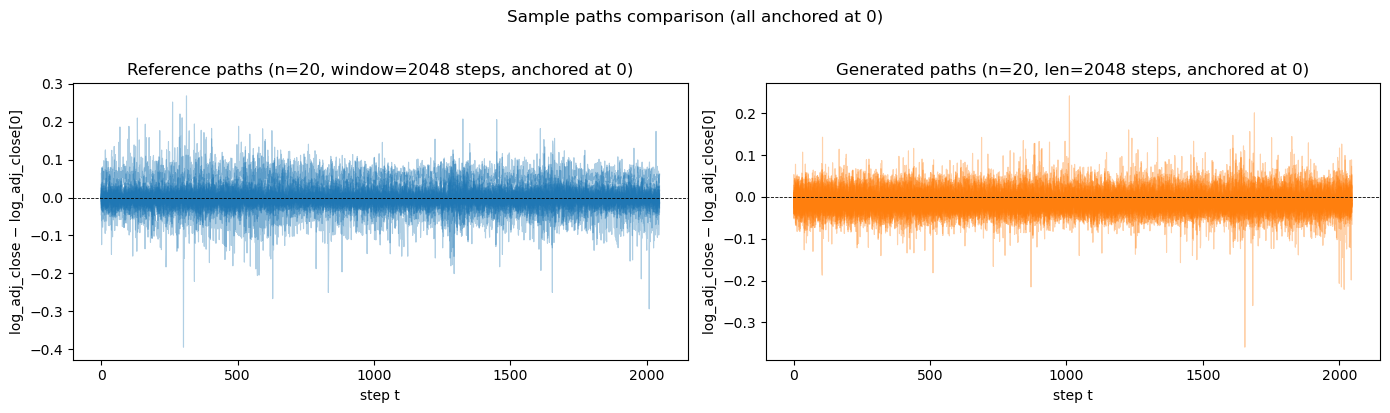

In [16]:
N_SHOW   = 20
GEN_LEN  = int(np.median(gen_lens))   # typical generated path length

# Sample random paths from each dataset
ref_idx = rng.choice(len(ref_paths), size=min(N_SHOW, len(ref_paths)), replace=False)
gen_idx = rng.choice(len(gen_paths), size=min(N_SHOW, len(gen_paths)), replace=False)

def extract_window(path: np.ndarray, window_len: int, rng: np.random.Generator) -> np.ndarray:
    """Extract a random window of `window_len` from `path`."""
    if len(path) <= window_len:
        return path
    start = rng.integers(0, len(path) - window_len + 1)
    return path[start : start + window_len]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Reference
ax = axes[0]
for i in ref_idx:
    p = extract_window(ref_paths[i], GEN_LEN, rng)
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Reference paths (n={len(ref_idx)}, window={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

# Generated
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i]
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:orange")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Generated paths (n={len(gen_idx)}, len={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

plt.suptitle("Sample paths comparison (all anchored at 0)", y=1.02)
plt.tight_layout()
plt.savefig
plt.savefig(f"../images/comparison/sample_paths_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 6. Autocorrelation: levels vs increments

**Rationale**:
- *Levels*: log-price paths should show high persistence (ACF ≈ 1, slow decay).
- *Increments*: log-returns should be nearly i.i.d. (ACF ≈ 0 at all lags ≥ 1).

We average ACFs across multiple paths for a stable estimate.  
For reference paths longer than `GEN_LEN` we extract the first `GEN_LEN` steps.

In [17]:
# N_ACF_PATHS = min(50, len(ref_paths), len(gen_paths))
# LAGS        = min(30, GEN_LEN // 2)

# def mean_acf_across_paths(
#     paths: list[np.ndarray],
#     n_paths: int,
#     lags: int,
#     use_diff: bool = False,
#     max_len: int | None = None,
#     rng: np.random.Generator | None = None,
# ) -> np.ndarray:
#     """Average ACF (lags 1..lags) across up to `n_paths` paths."""
#     indices = (
#         rng.choice(len(paths), size=n_paths, replace=False)
#         if rng is not None
#         else np.arange(min(n_paths, len(paths)))
#     )
#     acfs = []
#     for i in indices:
#         x = paths[i]
#         if max_len is not None and len(x) > max_len:
#             x = x[:max_len]   # align to generated path length
#         if use_diff:
#             x = np.diff(x)
#         if len(x) <= lags:
#             continue
#         acfs.append(sm_acf(x, nlags=lags, fft=True)[1:])   # skip lag-0 (=1)
#     return np.mean(acfs, axis=0) if acfs else np.zeros(lags)

# lag_axis = np.arange(1, LAGS + 1)

# ref_acf_lev = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=False, max_len=GEN_LEN, rng=rng)
# gen_acf_lev = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=False, max_len=None, rng=rng)
# ref_acf_inc = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=True,  max_len=GEN_LEN, rng=rng)
# gen_acf_inc = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=True,  max_len=None, rng=rng)

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ax = axes[0]
# ax.plot(lag_axis, ref_acf_lev, label="Reference", color="tab:blue",   linewidth=1.4)
# ax.plot(lag_axis, gen_acf_lev, label="Generated", color="tab:orange", linewidth=1.4)
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_title("ACF of levels  (should be ≈ 1, slow decay)")
# ax.set_xlabel("lag")
# ax.set_ylabel("autocorrelation")
# ax.set_ylim(-0.2, 1.05)
# ax.legend(fontsize=9)

# ax = axes[1]
# ax.plot(lag_axis, ref_acf_inc, label="Reference", color="tab:blue",   linewidth=1.4)
# ax.plot(lag_axis, gen_acf_inc, label="Generated", color="tab:orange", linewidth=1.4)
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_title("ACF of increments  (should be ≈ 0 at all lags)")
# ax.set_xlabel("lag")
# ax.set_ylabel("autocorrelation")
# ax.set_ylim(-0.3, 1.05)
# ax.legend(fontsize=9)

# plt.suptitle(f"Autocorrelation structure  (avg over {N_ACF_PATHS} paths)", y=1.02)
# plt.tight_layout()
# plt.show()

# print(f"Ref  level  ACF at lag-1: {ref_acf_lev[0]:.3f}  |  "
#       f"Gen  level  ACF at lag-1: {gen_acf_lev[0]:.3f}")
# print(f"Ref  inc    ACF at lag-1: {ref_acf_inc[0]:.3f}  |  "
#       f"Gen  inc    ACF at lag-1: {gen_acf_inc[0]:.3f}")

# 8. Paper's FTS evaluations metrics
These metrics are written to work on **LOG-RETURN**.

In [18]:
sys.path.append(os.path.abspath(".."))

import replication.stylized_facts as sf
import numpy as np

In [19]:
# Reference: full stock series (not windows)
ref_full = {}
for csv_path in sorted(Path(REF_DIRECTORY).glob("*.csv")):
    df = pd.read_csv(csv_path)
    ref_full[csv_path.stem] = df["log_adj_close"].to_numpy(dtype=float)

ref_full_obj    = np.empty(len(ref_full), dtype=object)
ref_full_pooled = np.concatenate(list(ref_full.values()))
for i, r in enumerate(ref_full.values()):
    ref_full_obj[i] = r

# Generated: already 2048-pt independent samples — use as-is
# gen_paths_obj and gen_paths_arr unchanged


In [20]:
# Use sf.distribution() with normalize=True and scale='log'
output_dir = Path("../images/stylized_facts_output_heavy_tails")
output_dir.mkdir(exist_ok=True, parents=True)


In [21]:
# Prepare data as object arrays (one array per path)
# ref_paths_arr = np.array(ref_paths, dtype=object)
# gen_paths_arr = np.array(gen_paths, dtype=object)

# Using np.concatenate
# ref_paths_arr = np.concatenate(ref_paths)
gen_paths_arr = np.concatenate(gen_paths)

# If ref_paths and gen_paths are lists:
# ref_paths_obj = np.empty(len(ref_paths), dtype=object)
# for i, r in enumerate(ref_paths):
#     ref_paths_obj[i] = r

gen_paths_obj = np.empty(len(gen_paths), dtype=object)
for i, g in enumerate(gen_paths):
    gen_paths_obj[i] = g

# Extract checkpoint names (last part after "/")
gen_checkpoint_name = os.path.basename(GEN_DIRECTORY.rstrip('/'))
ref_checkpoint_name = os.path.basename(REF_DIRECTORY.rstrip('/'))

In [22]:
# # print(ref_paths[:5], "\n", ref_paths.shape)
# print(ref_paths_arr[:5],"\n", ref_paths_arr.shape)
print(gen_paths_obj[:5],"\n", gen_paths_obj.shape)

[array([ 0.00754924,  0.01862241, -0.01048581, ...,  0.01626878,
         0.00854009, -0.00368014])
 array([-0.02870241,  0.00981543,  0.0128748 , ..., -0.00362173,
        -0.00963724, -0.00071077])
 array([ 0.00020923, -0.05162712,  0.00370442, ..., -0.00949151,
        -0.01543409, -0.01375496])
 array([ 0.00896609,  0.00970055, -0.01079246, ...,  0.00352244,
         0.00720174,  0.06454615])
 array([-1.51609555e-02, -1.68624020e-02, -5.49979740e-03, ...,
        -5.70263250e-03,  1.09078290e-02, -6.72928100e-05])    ] 
 (512,)


In [23]:
sf.distribution(
    ref_full_pooled,
    file_name=str(output_dir / f"generated_distribution_{ref_checkpoint_name}"),
    scale="log",
    multiple=False,
    normalize=True,
    granuality=100,
)

In [24]:
sf.distribution(
    gen_paths_arr,
    file_name=str(output_dir / f"generated_distribution_{gen_checkpoint_name}"),
    scale="log",
    multiple=False,
    normalize=True,
    granuality=100,
)

In [25]:
sf.acf(
    ref_full_obj,
    file_name=str(output_dir / f"reference_volatility_clustering_{ref_checkpoint_name}"),
    for_abs=True,
    multiple=True,
    fit=False,
    scale="log",
    max_lag=1000,
)


In [26]:
sf.acf(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_volatility_clustering__{gen_checkpoint_name}"),
    for_abs=True,
    multiple=True,
    fit=False,
    scale="log",
    max_lag=100,
)

In [27]:
ref_lev = sf.leverage_effect(
    ref_full_obj,
    file_name=str(output_dir / f"reference_leverage_effect_{ref_checkpoint_name}"),
    multiple=True,
    min_lag=1,
    max_lag=100,
)

gen_lev = sf.leverage_effect(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_leverage_effect_{gen_checkpoint_name}"),
    multiple=True,
    min_lag=1,
    max_lag=100,
)


# Previous implementation

In [28]:
# # ── Stylised-fact metric functions ────────────────────────────────────────────

# def estimate_tail_exponent(
#     returns: np.ndarray,
#     x_min: float | None = None,
#     x_min_quantile: float = 0.90,
#     tail: str = "both",
# ) -> dict:
#     """
#     Fit CCDF of |returns| in log-log space via OLS for |r| >= x_min.
#     P(|r|) ~ |r|^{-α}  ↔  CCDF(x) ~ x^{-(α-1)}  →  slope = -(α-1)  →  α = 1 - slope.

#     Parameters
#     ----------
#     x_min          : hard threshold; if None, derived from x_min_quantile
#     x_min_quantile : quantile of |r| used as lower bound for tail fit
#     tail           : "both" uses |r|; "right" uses r>0; "left" uses -(r<0)
#     """
#     r = np.asarray(returns, dtype=float)
#     r = r[np.isfinite(r)]
#     if tail == "right":
#         x = r[r > 0]
#     elif tail == "left":
#         x = -r[r < 0]
#     else:
#         x = np.abs(r[r != 0]) # we need different from 0 otherwise the log(0) breaks
#     x = np.sort(x)

#     if x_min is None:
#         x_min = float(np.quantile(x, x_min_quantile))

#     n_all  = len(x)
#     x_tail = x[x >= x_min]
#     n_tail = len(x_tail)
#     if n_tail < 10:
#         raise ValueError(
#             f"Only {n_tail} points ≥ x_min={x_min:.5f}; lower x_min_quantile")

#     # P(|r| ≥ x_tail[i]) = (n_tail − i) / n_all  (empirical CCDF, descending)
#     ccdf             = np.arange(n_tail, 0, -1) / n_all
#     slope, intercept = np.polyfit(np.log(x_tail), np.log(ccdf), 1)
#     alpha            = 1.0 - slope   # CCDF ~ x^{-(α-1)}  →  α = 1 - slope

#     return dict(alpha=alpha, x_min=x_min, n_tail=n_tail,
#                 x_tail=x_tail, ccdf=ccdf,
#                 slope=slope, intercept=intercept)


# def compute_abs_return_acf(
#     paths: list[np.ndarray],
#     max_lag: int = 50,
#     n_paths: int | None = None,
#     seed_rng: np.random.Generator | None = None,
# ) -> tuple[np.ndarray, np.ndarray]:
#     """
#     Average Corr(|r_t|, |r_{t+k}|) for k = 1..max_lag across paths.
#     Assumes paths are already log-returns.
#     Returns (lags, mean_acf).
#     """
#     n   = min(n_paths or len(paths), len(paths))
#     idx = (
#         seed_rng.choice(len(paths), size=n, replace=False)
#         if seed_rng is not None else np.arange(n)
#     )
#     acfs = []
#     for i in idx:
#         r     = np.asarray(paths[i]).astype(float)
#         abs_r = np.abs(r[np.isfinite(r)])
#         if len(abs_r) <= max_lag + 1:
#             continue
#         acfs.append(sm_acf(abs_r, nlags=max_lag, fft=True)[1:])

#     lags     = np.arange(1, max_lag + 1)
#     mean_acf = np.mean(acfs, axis=0) if acfs else np.zeros(max_lag)
#     return lags, mean_acf


# def compute_leverage_effect(
#     paths: list[np.ndarray],
#     max_lag: int = 50,
# ) -> tuple[np.ndarray, np.ndarray]:
#     """
#     L(k) = E[r_t · (r_{t+k}² − r_t²)] / E[r_t²]²   per window, then averaged.
#     Assumes paths are already log-returns.
#     Negative L(k) for small k signals the leverage effect.
#     Returns (lags, mean_L).
#     """
#     all_lk = []
#     for path in paths:
#         r = np.asarray(path).astype(float)
#         r = r[np.isfinite(r)]
#         n = len(r)
#         if n <= max_lag:
#             continue
#         denom = np.mean(r ** 2)
#         if denom < 1e-12:
#             continue
#         lk = np.array([
#             np.mean(r[: n - k] * (r[k:] ** 2 - r[: n - k] ** 2))
#             for k in range(1, max_lag + 1)
#         ]) / denom ** 2
#         all_lk.append(lk)

#     lags    = np.arange(1, max_lag + 1)
#     mean_lk = np.mean(all_lk, axis=0) if all_lk else np.zeros(max_lag)
#     return lags, mean_lk


### 8.1 Heavy tails

Log-log CCDF of absolute returns fitted above `x_min` (grey dotted line) with OLS.  
P(|r|) ~ |r|^{−α}  ↔  CCDF(x) ~ x^{−(α−1)}; reported α = 1 − slope.  
Real equity returns typically have α ≈ 3–5 ("cubic law"). Higher α means lighter tails.

In [29]:
# # ── Parameters ────────────────────────────────────────────────────────────────
# HT_X_MIN_QUANTILE = 0.90    # fit power law above this quantile of |r|
# HT_TAIL           = "both"  # "both" uses |r|; "right" / "left" for one-sided tail
# HT_MAX_SCATTER    = 2_000   # max scatter points per dataset (subsampled on log scale)

# # Compute ─────────────────────────────────────────────────────────────────────
# ht_results = {}
# for paths, label in [(ref_paths, "Reference"), (gen_paths, "Generated")]:
#     incs = np.concatenate([p for p in paths if len(p) > 1]) #first order difference
#     ht_results[label] = estimate_tail_exponent(
#         incs, x_min_quantile=HT_X_MIN_QUANTILE, tail=HT_TAIL
#     )

In [30]:
# plt.close("all")
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# colors = {"Reference": "tab:blue", "Generated": "tab:orange"}

# ht_results = {}

# for paths, label in [(ref_paths, "Reference"), (gen_paths, "Generated")]:
#     diffs = []
#     for p in paths:
#         if len(p) > 1:
#             d = np.diff(p)
#             if d.size:
#                 diffs.append(d.astype(np.float32, copy=False))  # reduce memory
#     if not diffs:
#         raise ValueError(f"No valid increments for {label}")

#     incs = np.concatenate(diffs)
#     del diffs

#     res = estimate_tail_exponent(
#         incs, x_min_quantile=HT_X_MIN_QUANTILE, tail=HT_TAIL
#     )
#     del incs

#     ht_results[label] = res

# for ax, (label, res) in zip(axes, ht_results.items()):
#     color = colors[label]

#     x_tail = np.asarray(res["x_tail"])
#     ccdf   = np.asarray(res["ccdf"])

#     # keep only finite positive values for log-log plotting
#     mask = np.isfinite(x_tail) & np.isfinite(ccdf) & (x_tail > 0) & (ccdf > 0)
#     x_tail = x_tail[mask]
#     ccdf   = ccdf[mask]

#     if len(x_tail) == 0:
#         ax.set_title(f"{label} — no valid tail points")
#         continue

#     n_sc = min(HT_MAX_SCATTER, len(x_tail))
#     sc_idx = np.unique(np.round(
#         np.logspace(0, np.log10(max(len(x_tail) - 1, 1)), n_sc)
#     ).astype(int))
#     sc_idx = sc_idx[sc_idx < len(x_tail)]

#     ax.scatter(
#         x_tail[sc_idx], ccdf[sc_idx],
#         s=6, alpha=0.5, color=color,
#         label=f"Empirical CCDF ({len(sc_idx)} pts)"
#     )

#     xmin = x_tail.min()
#     xmax = x_tail.max()
#     if np.isfinite(xmin) and np.isfinite(xmax) and xmin > 0 and xmax > xmin:
#         x_line = np.exp(np.linspace(np.log(xmin), np.log(xmax), 300))
#         ccdf_line = np.exp(res["slope"] * np.log(x_line) + res["intercept"])
#         valid_line = np.isfinite(ccdf_line) & (ccdf_line > 0)

#         ax.plot(
#             x_line[valid_line], ccdf_line[valid_line],
#             "--", color=color, linewidth=2.0,
#             label=f"OLS fit α = {res['alpha']:.2f} (n = {res['n_tail']})"
#         )

#     if np.isfinite(res["x_min"]) and res["x_min"] > 0:
#         ax.axvline(
#             res["x_min"], color="grey", linewidth=0.8, linestyle=":",
#             label=f"x_min = {res['x_min']:.4f}"
#         )

#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_title(f"{label} — α = {res['alpha']:.2f}")
#     ax.set_xlabel("|return| (log scale)")
#     ax.set_ylabel("P(|r| > x) [CCDF, log scale]")
#     ax.legend(fontsize=8)
#     ax.grid(True, linewidth=0.3)

# plt.tight_layout()
# plt.show()
# plt.close(fig)

### 8.2 Volatility clustering

Autocorrelation of **absolute returns** Corr(|r_t|, |r_{t+k}|) for k = 1 … max_lag.  
Real log-returns show slowly decaying positive ACF of |r_t| (ARCH/GARCH effect).  
i.i.d. noise would give ACF ≈ 0 at all lags.

In [31]:
# # ── Parameters ────────────────────────────────────────────────────────────────
# VC_MAX_LAG = 50
# VC_N_PATHS = min(100, len(ref_paths), len(gen_paths))

# # Compute ─────────────────────────────────────────────────────────────────────
# ref_vc_lags, ref_vc_acf = compute_abs_return_acf(
#     ref_paths, max_lag=VC_MAX_LAG, n_paths=VC_N_PATHS, seed_rng=rng)
# gen_vc_lags, gen_vc_acf = compute_abs_return_acf(
#     gen_paths, max_lag=VC_MAX_LAG, n_paths=VC_N_PATHS, seed_rng=rng)

# # Plot ────────────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot(ref_vc_lags, ref_vc_acf, color="tab:blue",   linewidth=1.6, label="Reference")
# ax.plot(gen_vc_lags, gen_vc_acf, color="tab:orange", linewidth=1.6, label="Generated")
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_xlabel("lag k")
# ax.set_ylabel("Corr(|r_t|, |r_{t+k}|)")
# ax.set_title(
#     f"Volatility clustering — ACF of |returns|\n"
#     f"(avg over {VC_N_PATHS} paths, max_lag={VC_MAX_LAG})"
# )
# ax.legend(fontsize=9)
# ax.grid(True, linewidth=0.3)
# plt.tight_layout()
# plt.show()

# print(f"Ref  ACF(|r|) at lag 1 : {ref_vc_acf[0]:.4f}  (>0 → clustering present)")
# print(f"Gen  ACF(|r|) at lag 1 : {gen_vc_acf[0]:.4f}  (>0 → clustering present)")

### 8.3 Leverage effect

L(k) = E[r_t (r_{t+k}² − r_t²)] / E[r_t²]²   computed per window and averaged across windows.  
Negative L(k) for small k means past negative returns predict higher future volatility (leverage).  
Note: log-returns here are `np.diff(log_adj_close)`, i.e. the increments used throughout.

In [32]:
# # ── Parameters ────────────────────────────────────────────────────────────────
# LE_MAX_LAG = 100

# # Compute ─────────────────────────────────────────────────────────────────────
# ref_le_lags, ref_le = compute_leverage_effect(ref_paths, max_lag=LE_MAX_LAG)
# gen_le_lags, gen_le = compute_leverage_effect(gen_paths, max_lag=LE_MAX_LAG)

# # Plot ────────────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot(ref_le_lags, ref_le, color="tab:blue",   linewidth=1.6, label="Reference")
# ax.plot(gen_le_lags, gen_le, color="tab:orange", linewidth=1.6, label="Generated")
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_xlabel("lag k")
# ax.set_ylabel("L(k)")
# ax.set_title(
#     r"Leverage effect  $L(k) = \mathbb{E}[r_t(r_{t+k}^2 - r_t^2)] \,/\, \mathbb{E}[r_t^2]^2$"
#     f"\n(max_lag={LE_MAX_LAG})"
# )
# ax.legend(fontsize=9)
# ax.grid(True, linewidth=0.3)
# plt.tight_layout()
# plt.show()

# print(f"Ref  L(1) = {ref_le[0]:.6f}  (negative → leverage effect present)")
# print(f"Gen  L(1) = {gen_le[0]:.6f}  (negative → leverage effect present)")

### 8.4 Combined stylised-facts summary: PDF of normalised returns · ACF per lag · Leverage effect

In [33]:
# # ── Parameters ────────────────────────────────────────────────────────────────
# PDF_N_BINS   = 120       # histogram bins for normalised-return PDF
# PDF_CLIP_STD = 6         # clip normalised returns to ±PDF_CLIP_STD for readability
# ACF_MAX_LAG  = 50        # lags for both ACF and leverage effect
# ACF_N_PATHS  = min(200, len(ref_paths), len(gen_paths))

# from scipy.stats import gaussian_kde

# # ── 1. Normalised log-returns ─────────────────────────────────────────────────
# def normalised_returns(paths: list[np.ndarray]) -> np.ndarray:
#     """Per-path z-score of increments, then pooled across all paths."""
#     normed = []
#     for p in paths:
#         r = np.diff(p.astype(np.float64))
#         s = r.std()
#         if s > 1e-12:
#             normed.append(r / s)
#     return np.concatenate(normed) if normed else np.array([])

# ref_norm = normalised_returns(ref_paths)
# gen_norm = normalised_returns(gen_paths)

# # clip extreme outliers only for plotting
# ref_norm_clipped = np.clip(ref_norm, -PDF_CLIP_STD, PDF_CLIP_STD)
# gen_norm_clipped = np.clip(gen_norm, -PDF_CLIP_STD, PDF_CLIP_STD)

# bins = np.linspace(-PDF_CLIP_STD, PDF_CLIP_STD, PDF_N_BINS + 1)
# xs   = np.linspace(-PDF_CLIP_STD, PDF_CLIP_STD, 500)

# ref_kde = gaussian_kde(ref_norm_clipped)
# gen_kde = gaussian_kde(gen_norm_clipped)

# # reference Gaussian for comparison
# from scipy.stats import norm as sp_norm
# gauss_pdf = sp_norm.pdf(xs)

# # ── 2. ACF of |returns| (volatility clustering) ───────────────────────────────
# acf_lags, ref_acf = compute_abs_return_acf(
#     ref_paths, max_lag=ACF_MAX_LAG, n_paths=ACF_N_PATHS, seed_rng=rng)
# _,         gen_acf = compute_abs_return_acf(
#     gen_paths, max_lag=ACF_MAX_LAG, n_paths=ACF_N_PATHS, seed_rng=rng)

# # ── 3. Leverage effect ────────────────────────────────────────────────────────
# le_lags, ref_le = compute_leverage_effect(ref_paths, max_lag=ACF_MAX_LAG)
# _,       gen_le = compute_leverage_effect(gen_paths, max_lag=ACF_MAX_LAG)

# # ── Plot ──────────────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# # (a) PDF of normalised returns
# ax = axes[0]
# ax.hist(ref_norm_clipped, bins=bins, density=True,
#         alpha=0.30, color="tab:blue",   label="Reference")
# ax.hist(gen_norm_clipped, bins=bins, density=True,
#         alpha=0.30, color="tab:orange", label="Generated")
# ax.plot(xs, ref_kde(xs), color="tab:blue",   linewidth=1.8)
# ax.plot(xs, gen_kde(xs), color="tab:orange", linewidth=1.8)
# ax.plot(xs, gauss_pdf,   color="black", linewidth=1.2,
#         linestyle="--", label="N(0,1)")
# ax.set_yscale("log")
# ax.set_xlim(-PDF_CLIP_STD, PDF_CLIP_STD)
# ax.set_xlabel("normalised return  r / σ")
# ax.set_ylabel("density  (log scale)")
# ax.set_title("PDF of normalised log-returns\n(fat tails ↔ heavier than Gaussian)")
# ax.legend(fontsize=8)
# ax.grid(True, linewidth=0.3)

# # (b) ACF of |returns|
# ax = axes[1]
# ax.plot(acf_lags, ref_acf, color="tab:blue",   linewidth=1.8, label="Reference")
# ax.plot(acf_lags, gen_acf, color="tab:orange", linewidth=1.8, label="Generated")
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_xlabel("lag  k")
# ax.set_ylabel("Corr(|r_t|, |r_{t+k}|)")
# ax.set_title(
#     f"Autocorrelation of |returns| per lag\n"
#     f"(volatility clustering; avg over {ACF_N_PATHS} paths)"
# )
# ax.legend(fontsize=8)
# ax.grid(True, linewidth=0.3)

# # (c) Leverage effect
# ax = axes[2]
# ax.plot(le_lags, ref_le, color="tab:blue",   linewidth=1.8, label="Reference")
# ax.plot(le_lags, gen_le, color="tab:orange", linewidth=1.8, label="Generated")
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_xlabel("lag  k")
# ax.set_ylabel("L(k)")
# ax.set_title(
#     r"Leverage effect  $L(k)$  per lag"
#     "\n(negative for small k → leverage present)"
# )
# ax.legend(fontsize=8)
# ax.grid(True, linewidth=0.3)

# plt.suptitle("Stylised facts — Reference vs Generated", fontsize=13, y=1.02)
# plt.tight_layout()
# plt.show()

# print(f"PDF  | ref excess kurtosis: {scipy_stats.kurtosis(ref_norm, fisher=True):.3f}"
#       f"  |  gen: {scipy_stats.kurtosis(gen_norm, fisher=True):.3f}")
# print(f"ACF  | ref lag-1: {ref_acf[0]:.4f}  |  gen lag-1: {gen_acf[0]:.4f}")
# print(f"Lev  | ref L(1): {ref_le[0]:.6f}  |  gen L(1): {gen_le[0]:.6f}")

## 7. Interpretation guide

| Test | Passing | Failing |
|------|---------|--------|
| **Level KS** (§3) | p > 0.05; QQ on diagonal | S-curve in QQ; large KS stat |
| **Increment KS** (§4) | p > 0.05; QQ on diagonal | Tail mismatch (fat tails not reproduced) |
| **Sample paths** (§5) | Similar scale, fan-out, no collapse | Paths cluster / diverge / show periodicity |
| **Level ACF** (§6) | High persistence (ACF ≈ 1, slow decay) | Geometric decay → AR-like collapse |
| **Increment ACF** (§6) | ACF ≈ 0 at all lags ≥ 1 | Positive ACF → spurious momentum |

**Note on fat tails**: real log-returns have excess kurtosis > 0.  
A model that reproduces the increment std but not the kurtosis has learned the scale but
not the tail structure — visible as an S-curve on the increment QQ plot.